In [54]:
# =========================
# 0. Imports
# =========================
import math
from functools import partial
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment

import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt

from ott.geometry import pointcloud
from ott.problems.linear import linear_problem
from ott.solvers.linear import sinkhorn

key = jax.random.PRNGKey(0)

In [55]:
# =========================
# 1. Toy 2D samplers
# =========================
def sample_gaussian(key, n, mean=(0.0, 0.0), scale=1.0):
    mean = jnp.array(mean)
    x = jax.random.normal(key, (n, 2))
    return mean + scale * x

def sample_8gaussians(key, n, radius=5.0, std=0.4):
    centers = jnp.array([
        [1.0, 0.0], [-1.0, 0.0], [0.0, 1.0], [0.0, -1.0],
        [1.0 / jnp.sqrt(2), 1.0 / jnp.sqrt(2)],
        [1.0 / jnp.sqrt(2), -1.0 / jnp.sqrt(2)],
        [-1.0 / jnp.sqrt(2), 1.0 / jnp.sqrt(2)],
        [-1.0 / jnp.sqrt(2), -1.0 / jnp.sqrt(2)],
    ]) * radius
    k1, k2 = jax.random.split(key)
    idx = jax.random.randint(k1, (n,), 0, 8)
    noise = std * jax.random.normal(k2, (n, 2))
    return centers[idx] + noise

def sample_moons(key, n, noise=0.08):
    n1 = n // 2
    n2 = n - n1
    k1, k2, k3 = jax.random.split(key, 3)

    t1 = jax.random.uniform(k1, (n1,), minval=0.0, maxval=jnp.pi)
    moon1 = jnp.stack([jnp.cos(t1), jnp.sin(t1)], axis=1)

    t2 = jax.random.uniform(k2, (n2,), minval=0.0, maxval=jnp.pi)
    moon2 = jnp.stack([1.0 - jnp.cos(t2), 1.0 - jnp.sin(t2) - 0.5], axis=1)

    x = jnp.concatenate([moon1, moon2], axis=0)
    x = x + noise * jax.random.normal(k3, x.shape)
    return 3.0 * x

In [56]:
# =========================
# 2. Pairing functions
# =========================
def independent_pairing(x0, x1):
    # Just pair by index after independent sampling
    return x0, x1

def sinkhorn_coupling(x0, x1, epsilon=0.1):
    geom = pointcloud.PointCloud(x0, x1, epsilon=epsilon)
    prob = linear_problem.LinearProblem(geom)
    solver = sinkhorn.Sinkhorn()
    out = solver(prob)
    # transport matrix
    P = out.matrix
    return P, out

def sample_pairs_from_coupling(key, x0, x1, P):
    row_sums = jnp.sum(P, axis=1, keepdims=True) + 1e-12
    probs = P / row_sums

    n = x0.shape[0]
    keys = jax.random.split(key, n)

    sampled_indices = jnp.array([
        jax.random.choice(keys[i], x1.shape[0], p=probs[i])
        for i in range(n)
    ])

    paired_x1 = x1[sampled_indices]
    return x0, paired_x1

def hungarian_pairing(x0, x1):
    # Exact linear assignment on squared Euclidean cost
    C = jnp.sum((x0[:, None, :] - x1[None, :, :]) ** 2, axis=-1)  # (n, n)
    _, col_ind = linear_sum_assignment(np.asarray(C))
    return x0, x1[jnp.array(col_ind)]

def sinkhorn_barycentric_pairing(x0, x1, P):
    # Barycentric target y_i = sum_j P_ij x1_j / sum_j P_ij
    row_sums = jnp.sum(P, axis=1, keepdims=True) + 1e-12
    W = P / row_sums
    x1_bar = W @ x1
    return x0, x1_bar

In [57]:
# =========================
# 3. Simple MLP in raw JAX
# =========================
def init_mlp_params(key, widths):
    params = []
    keys = jax.random.split(key, len(widths) - 1)
    for k, (din, dout) in zip(keys, zip(widths[:-1], widths[1:])):
        w_key, _ = jax.random.split(k)
        W = 0.1 * jax.random.normal(w_key, (din, dout))
        b = jnp.zeros((dout,))
        params.append((W, b))
    return params

def mlp_apply(params, x):
    h = x
    for i, (W, b) in enumerate(params):
        h = h @ W + b
        if i < len(params) - 1:
            h = jax.nn.silu(h)
    return h

def vf_apply(params, x, t):
    # x: (batch, 2), t: (batch, 1)
    inp = jnp.concatenate([x, t], axis=1)  # shape (batch, 3)
    return mlp_apply(params, inp)          # shape (batch, 2)

In [58]:
# =========================
# 4. Flow-matching loss
# =========================
def fm_loss(params, x0, x1, t):
    # linear interpolation path
    xt = (1.0 - t) * x0 + t * x1
    target_v = x1 - x0
    pred_v = vf_apply(params, xt, t)
    return jnp.mean(jnp.sum((pred_v - target_v) ** 2, axis=1))

In [59]:
# =========================
# 5. Training step
# =========================
optimizer = optax.adam(1e-3)

@jax.jit
def train_step(params, opt_state, x0, x1, t):
    loss, grads = jax.value_and_grad(fm_loss)(params, x0, x1, t)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

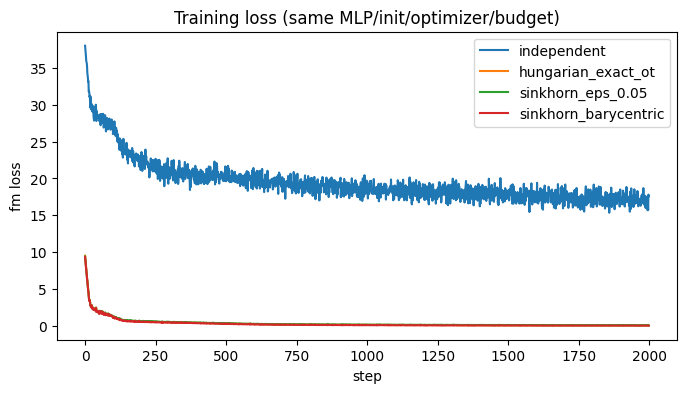

In [60]:
# =========================
# 6. Unified setup + training (4 couplings)
# =========================
n = 500
eps = 0.05
train_steps = 2000
rollout_steps = 32
widths = [3, 128, 128, 128, 2]

# Data + keys
key, k0, k1, kpair, kinit = jax.random.split(key, 5)
x0 = sample_moons(k0, n)
x1 = sample_8gaussians(k1, n)

# Couplings
x0_ind, x1_ind = independent_pairing(x0, x1)

x0_hun, x1_hun = hungarian_pairing(x0, x1)

P, out = sinkhorn_coupling(x0, x1, epsilon=eps)
x0_sink, x1_sink = sample_pairs_from_coupling(kpair, x0, x1, P)

x0_bar, x1_bar = sinkhorn_barycentric_pairing(x0, x1, P)

# Same rollout solver for all
def rollout_euler(params, x_init, steps=32):
    dt = 1.0 / steps
    x = x_init
    traj = [x]
    for k in range(steps):
        tval = jnp.full((x.shape[0], 1), k / steps)
        v = vf_apply(params, x, tval)
        x = x + dt * v
        traj.append(x)
    return traj

# Same init for all experiments
base_params = init_mlp_params(kinit, widths)

def make_t_schedule(seed, steps, n):
    k = jax.random.PRNGKey(seed)
    keys = jax.random.split(k, steps)
    return [jax.random.uniform(ki, (n, 1)) for ki in keys]

t_schedule = make_t_schedule(seed=123, steps=train_steps, n=n)

def train_on_fixed_pairs(params0, x0_pair, x1_pair, t_schedule):
    params = params0
    opt_state = optimizer.init(params)
    losses = []
    for t in t_schedule:
        params, opt_state, loss = train_step(params, opt_state, x0_pair, x1_pair, t)
        losses.append(float(loss))
    return params, np.array(losses)

couplings = {
    "independent": (x0_ind, x1_ind),
    "hungarian_exact_ot": (x0_hun, x1_hun),
    f"sinkhorn_eps_{eps}": (x0_sink, x1_sink),
    "sinkhorn_barycentric": (x0_bar, x1_bar),
}

results = {}
for name, (xa, xb) in couplings.items():
    params_tr, losses = train_on_fixed_pairs(base_params, xa, xb, t_schedule)
    traj = rollout_euler(params_tr, x0[:200], steps=rollout_steps)
    results[name] = {"params": params_tr, "losses": losses, "traj": traj}

# Loss curves
plt.figure(figsize=(8, 4))
for name, r in results.items():
    plt.plot(r["losses"], label=name)
plt.title("Training loss (same MLP/init/optimizer/budget)")
plt.xlabel("step")
plt.ylabel("fm loss")
plt.legend()
plt.show()


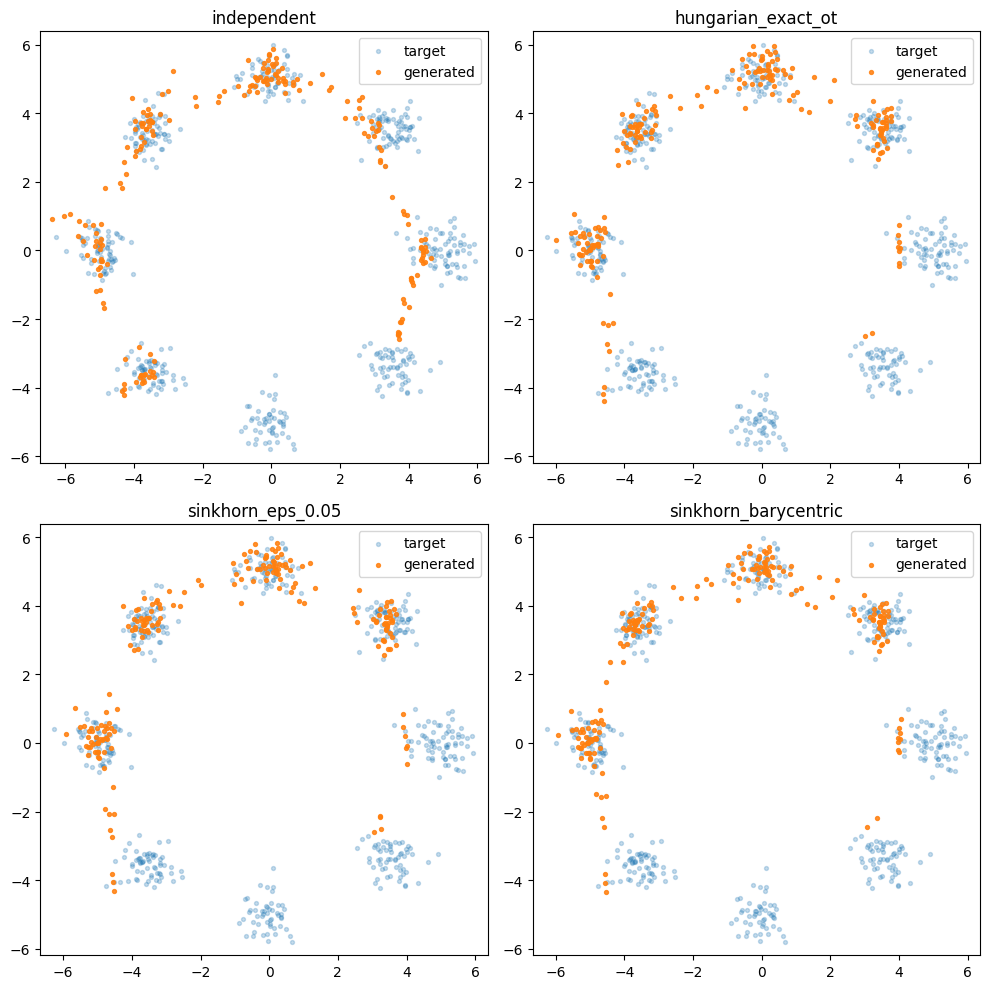

In [61]:
# =========================
# 7. Final generated samples per coupling
# =========================
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, (name, r) in zip(axes.ravel(), results.items()):
    gen = r["traj"][-1]
    ax.scatter(x1[:, 0], x1[:, 1], s=8, alpha=0.25, label="target")
    ax.scatter(gen[:, 0], gen[:, 1], s=8, alpha=0.85, label="generated")
    ax.set_title(name)
    ax.axis("equal")
    ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


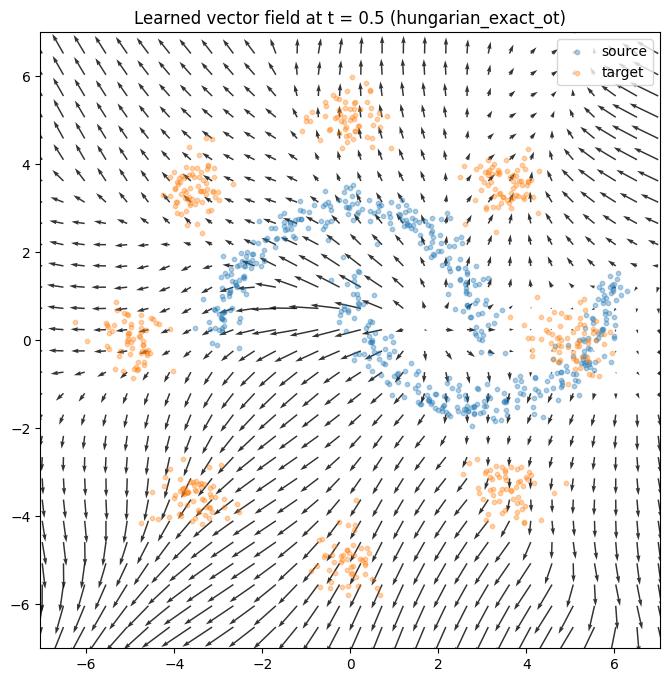

In [62]:
# =========================
# 8. Vector field at t=0.5 for one selected coupling
# =========================
selected_name = "hungarian_exact_ot"  # change if you want another one
params_sel = results[selected_name]["params"]

grid_x = jnp.linspace(-7, 7, 30)
grid_y = jnp.linspace(-7, 7, 30)
xx, yy = jnp.meshgrid(grid_x, grid_y)
points = jnp.stack([xx.ravel(), yy.ravel()], axis=1)

t = 0.5 * jnp.ones((points.shape[0], 1))
v = vf_apply(params_sel, points, t)

u = np.array(v[:, 0]).reshape(xx.shape)
w = np.array(v[:, 1]).reshape(yy.shape)

plt.figure(figsize=(8, 8))
plt.quiver(np.array(xx), np.array(yy), u, w, angles="xy", scale_units="xy", scale=10, alpha=0.8)
plt.scatter(np.array(x0[:, 0]), np.array(x0[:, 1]), s=10, alpha=0.35, label="source")
plt.scatter(np.array(x1[:, 0]), np.array(x1[:, 1]), s=10, alpha=0.35, label="target")
plt.title(f"Learned vector field at t = 0.5 ({selected_name})")
plt.legend()
plt.axis("equal")
plt.xlim(-7, 7)
plt.ylim(-7, 7)
plt.show()


=== Summary metrics per coupling ===


,coupling,PE,NPE,W2_data_sq,endpoint_W2_sq_at_32,loss_mean,loss_var,target_velocity_kernel_var
0,hungarian_exact_ot,9.418300,0.001556,9.403669,0.185736,0.353438,0.488526,0.494333
1,independent,20.788878,1.210720,9.403669,0.704875,19.471356,8.647886,26.632931
2,sinkhorn_barycentric,9.169506,0.024901,9.403669,0.128623,0.316349,0.472240,0.435645
3,sinkhorn_eps_0.05,9.319196,0.008983,9.403669,0.215198,0.378346,0.470664,0.502341



=== Low-NFE endpoint W2^2 (head) ===


,coupling,nfe,endpoint_w2_sq
0,independent,4,2.224660
1,independent,8,1.177041
2,independent,16,0.855842
3,independent,32,0.704875
4,independent,64,0.647633


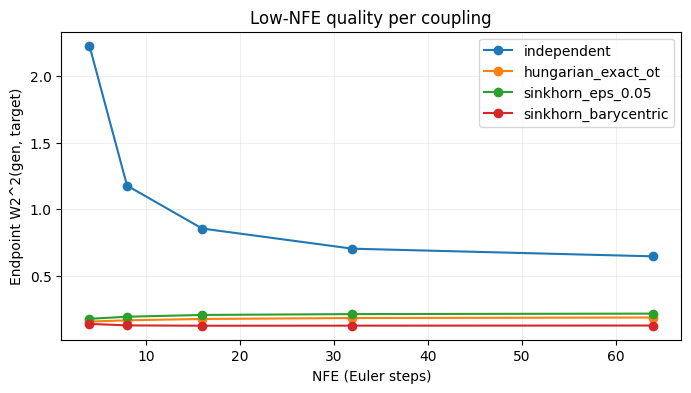

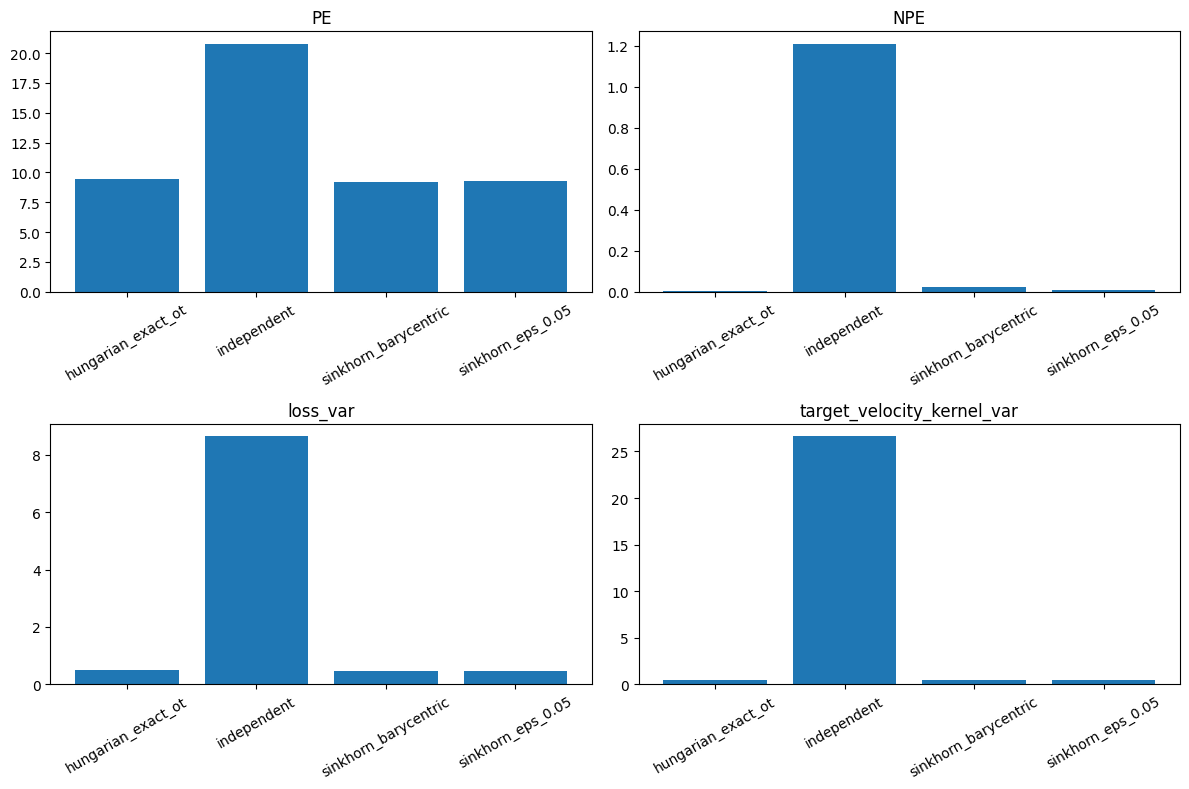

In [65]:
# =========================
# 9. Metrics for each coupling: PE, endpoint W2^2, low-NFE, training proxies
# =========================

# ---------- helpers ----------
def empirical_w2_squared_hungarian(A, B):
    """
    A, B: (n, d), equal n
    Returns average squared matching cost.
    """
    C = jnp.sum((A[:, None, :] - B[None, :, :]) ** 2, axis=-1)  # (n,n)
    row_ind, col_ind = linear_sum_assignment(np.asarray(C))
    return float(np.asarray(C)[row_ind, col_ind].mean())

def rollout_euler_final(params, x_init, steps):
    dt = 1.0 / steps
    x = x_init
    for k in range(steps):
        tval = jnp.full((x.shape[0], 1), k / steps)
        v = vf_apply(params, x, tval)
        x = x + dt * v
    return x

def path_energy(params, x_init, steps=256):
    """
    PE = E \int_0^1 ||v(x_t,t)||^2 dt
    estimated by Euler quadrature along rollout trajectories.
    """
    dt = 1.0 / steps
    x = x_init
    acc = 0.0
    for k in range(steps):
        tval = jnp.full((x.shape[0], 1), k / steps)
        v = vf_apply(params, x, tval)
        acc += float(jnp.mean(jnp.sum(v * v, axis=1))) * dt
        x = x + dt * v
    return acc

def velocity_variance_kernel(
    xa,
    xb,
    n_time_samples=8,
    sigma=0.5,
    key=jax.random.PRNGKey(0),
    n_query=1024,
    n_ref=2048,
    include_time=False,
    time_scale=1.0,
):
    """
    Estimate E[ Var(v | x_t) ] using kernel conditional moments.
    Uses subsampling for CPU-friendly runtime.
    """
    N, d = xa.shape
    vel0 = xb - xa  # (N, d)

    key_t, key_q, key_r = jax.random.split(key, 3)
    t = jax.random.uniform(key_t, (n_time_samples, N, 1))  # (T,N,1)

    xt = (1.0 - t) * xa[None, :, :] + t * xb[None, :, :]   # (T,N,d)
    vel = jnp.broadcast_to(vel0[None, :, :], (n_time_samples, N, d))  # (T,N,d)

    xt = xt.reshape(-1, d)
    vel = vel.reshape(-1, d)
    t_flat = t.reshape(-1, 1)
    M = xt.shape[0]

    feat = jnp.concatenate([xt, time_scale * t_flat], axis=1) if include_time else xt

    nq = int(min(n_query, M))
    nr = int(min(n_ref, M))

    q_idx = jax.random.choice(key_q, M, shape=(nq,), replace=False)
    r_idx = jax.random.choice(key_r, M, shape=(nr,), replace=False)

    fq = feat[q_idx]      # (nq, fdim)
    fr = feat[r_idx]      # (nr, fdim)
    v_ref = vel[r_idx]    # (nr, d)

    diff = fq[:, None, :] - fr[None, :, :]
    dist2 = jnp.sum(diff**2, axis=-1)

    K = jnp.exp(-dist2 / (2.0 * sigma**2))
    K = K / (jnp.sum(K, axis=1, keepdims=True) + 1e-8)

    mean_v = K @ v_ref
    mean_v2 = K @ (v_ref**2)

    var = jnp.maximum(mean_v2 - mean_v**2, 0.0)
    local_var = jnp.sum(var, axis=1)

    return jnp.mean(local_var)

# ---------- constants ----------
n_eval = min(x0.shape[0], x1.shape[0])   # keep equal size
x0_eval = x0[:n_eval]
x1_eval = x1[:n_eval]

# W2^2(mu0, mu1) baseline for NPE
w2_data = empirical_w2_squared_hungarian(x0_eval, x1_eval)

nfe_list = [4, 8, 16, 32, 64]

# ---------- per-coupling metrics ----------
summary_rows = []
low_nfe_rows = []

for name, r in results.items():
    params = r["params"]
    losses = np.asarray(r["losses"])

    # (1) Path energy + NPE
    pe = path_energy(params, x0_eval, steps=256)
    npe = abs(pe - w2_data) / (w2_data + 1e-12)

    # (2) Endpoint transport error at default rollout budget
    x_gen_32 = rollout_euler_final(params, x0_eval, steps=32)
    w2_endpoint_32 = empirical_w2_squared_hungarian(x_gen_32, x1_eval)

    # (3) Low-NFE quality: endpoint W2^2 vs NFE
    for nfe in nfe_list:
        x_gen = rollout_euler_final(params, x0_eval, steps=nfe)
        w2_ep = empirical_w2_squared_hungarian(x_gen, x1_eval)
        low_nfe_rows.append({"coupling": name, "nfe": nfe, "endpoint_w2_sq": w2_ep})

    # (4) Training difficulty proxies
    loss_var = float(np.var(losses))
    xa, xb = couplings[name]

    key, kv = jax.random.split(key)
    target_velocity_kernel_var = float(
        velocity_variance_kernel(
            xa, xb,
            n_time_samples=8,
            sigma=0.6,
            key=kv,
            n_query=1024,
            n_ref=2048,
            include_time=True,
            time_scale=1.0,
        )
    )

    summary_rows.append({
        "coupling": name,
        "PE": pe,
        "NPE": npe,
        "W2_data_sq": w2_data,
        "endpoint_W2_sq_at_32": w2_endpoint_32,
        "loss_mean": float(np.mean(losses)),
        "loss_var": loss_var,
        "target_velocity_kernel_var": target_velocity_kernel_var,
    })

summary_df = pd.DataFrame(summary_rows).sort_values("coupling").reset_index(drop=True)
low_nfe_df = pd.DataFrame(low_nfe_rows)

print("=== Summary metrics per coupling ===")
display(summary_df)

print("\n=== Low-NFE endpoint W2^2 (head) ===")
display(low_nfe_df.head())

# ---------- plots ----------
# low-NFE curves
plt.figure(figsize=(8, 4))
for name in low_nfe_df["coupling"].unique():
    d = low_nfe_df[low_nfe_df["coupling"] == name].sort_values("nfe")
    plt.plot(d["nfe"], d["endpoint_w2_sq"], marker="o", label=name)
plt.xlabel("NFE (Euler steps)")
plt.ylabel("Endpoint W2^2(gen, target)")
plt.title("Low-NFE quality per coupling")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# summary bar plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
metrics_to_plot = ["PE", "NPE", "loss_var", "target_velocity_kernel_var"]
for ax, m in zip(axes.ravel(), metrics_to_plot):
    ax.bar(summary_df["coupling"], summary_df[m])
    ax.set_title(m)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


=== Trajectory curvature metrics ===


,coupling,vel_diff_sq,ang_dev
0,hungarian_exact_ot,0.000091,0.000011
1,independent,0.015978,0.001997
2,sinkhorn_barycentric,0.000066,0.000009
3,sinkhorn_eps_0.05,0.000096,0.000011


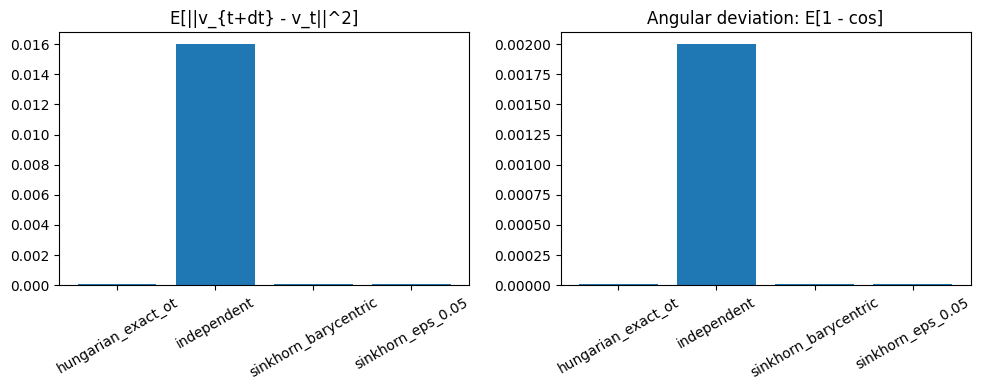

In [66]:
# =========================
# 10. Trajectory curvature / angular deviation (per coupling)
# =========================

def trajectory_curvature_metrics(params, x_init, steps=128, eps=1e-8):
    """
    Computes two curvature-style metrics along Euler trajectories:
    1) vel_diff_sq: E[ ||v_{t+dt} - v_t||^2 ]
    2) ang_dev:     E[ 1 - cos(v_{t+dt}, v_t) ]  (0 = perfectly aligned)
    """
    dt = 1.0 / steps
    x = x_init

    vel_diffs = []
    ang_devs = []

    # first velocity
    t0 = jnp.zeros((x.shape[0], 1))
    v_prev = vf_apply(params, x, t0)

    for k in range(1, steps + 1):
        # advance state with previous velocity
        x = x + dt * v_prev

        tval = jnp.full((x.shape[0], 1), k / steps)
        v_curr = vf_apply(params, x, tval)

        # squared velocity increment
        dv2 = jnp.sum((v_curr - v_prev) ** 2, axis=1)
        vel_diffs.append(jnp.mean(dv2))

        # angular deviation = 1 - cosine similarity
        num = jnp.sum(v_curr * v_prev, axis=1)
        den = (jnp.linalg.norm(v_curr, axis=1) * jnp.linalg.norm(v_prev, axis=1) + eps)
        cos = jnp.clip(num / den, -1.0, 1.0)
        ang = 1.0 - cos
        ang_devs.append(jnp.mean(ang))

        v_prev = v_curr

    return {
        "vel_diff_sq": float(jnp.mean(jnp.stack(vel_diffs))),
        "ang_dev": float(jnp.mean(jnp.stack(ang_devs))),
    }

# evaluate on same source subset for fairness
x_curv = x0_eval  # from previous metrics cell

curv_rows = []
for name, r in results.items():
    m = trajectory_curvature_metrics(r["params"], x_curv, steps=128)
    curv_rows.append({"coupling": name, **m})

curv_df = pd.DataFrame(curv_rows).sort_values("coupling").reset_index(drop=True)
print("=== Trajectory curvature metrics ===")
display(curv_df)

# plots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(curv_df["coupling"], curv_df["vel_diff_sq"])
axes[0].set_title("E[||v_{t+dt} - v_t||^2]")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(curv_df["coupling"], curv_df["ang_dev"])
axes[1].set_title("Angular deviation: E[1 - cos]")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()
